In [128]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, optimize_assets, fit_strategy
from src.strategy import (
    logistic_strategy, 
    momentum_strategy, 
    momentum_volatility_strategy, 
    mean_reversion_strategy, 
    momentum_trend_strategy, 
    momentum_voluratio_strategy,
    randforest_strategy
)
from src.visualization import plot_performance
from src.ml import build_ml_dataset, train_logistic, train_randforest
from src.finance import calculate_beta

## Beta Analysis

In [129]:
spy_df = get_data("SPY", "2016-01-01", "2026-01-01")
spy_df = generate_features(spy_df)

market_returns = spy_df["returns"].dropna()

[*********************100%***********************]  1 of 1 completed


In [130]:
df = pd.read_csv("../outputs/experiment_results.csv")

asset_avg = (
    df.groupby("Asset")["Test Sharpe"]
      .mean()
      .sort_values(ascending=False)
)

In [131]:
columns = ['Asset', 'Beta', 'Avg Test Sharpe']
df = pd.DataFrame(columns = columns)

In [132]:
assets = ['AAPL', 'MSFT','NVDA','TTD','DOCS','IBM','BE','XOM','GLD','JNJ','SCCO','ECL','JPM','META']

In [133]:
for asset in assets:
    asset_df = get_data(asset, "2016-01-01", "2026-01-01")
    asset_df = generate_features(asset_df)

    combined = pd.concat(
        [
            asset_df["returns"],
            spy_df["returns"]
        ],
        axis=1
    ).dropna()

    beta = calculate_beta(
        combined.iloc[:, 0],
        combined.iloc[:, 1]
    )

    df.loc[len(df)] = [asset, beta, asset_avg[asset]]

df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/var/folders/f5/793n94tx3jj8c_rrt1drx2g40000gn/T/ipykernel_68201/4086232039.py:5: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(
[*********************100%***********************]  1 of 1 completed
/var/folders/f5/793n94tx3jj8c_rrt1drx2g40000gn/T/ipykernel_68201/4086232039.py:5: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True`

,Asset,Beta,Avg Test Sharpe
0,AAPL,1.213043,0.882430
1,MSFT,1.178747,0.719039
2,NVDA,1.798033,1.456602
3,TTD,1.773262,-0.160005
4,DOCS,1.488148,0.324593
5,IBM,0.821961,1.043633
6,BE,1.842010,0.665593
7,XOM,0.812041,-0.038507
8,GLD,0.041616,1.433605
9,JNJ,0.462261,0.544844


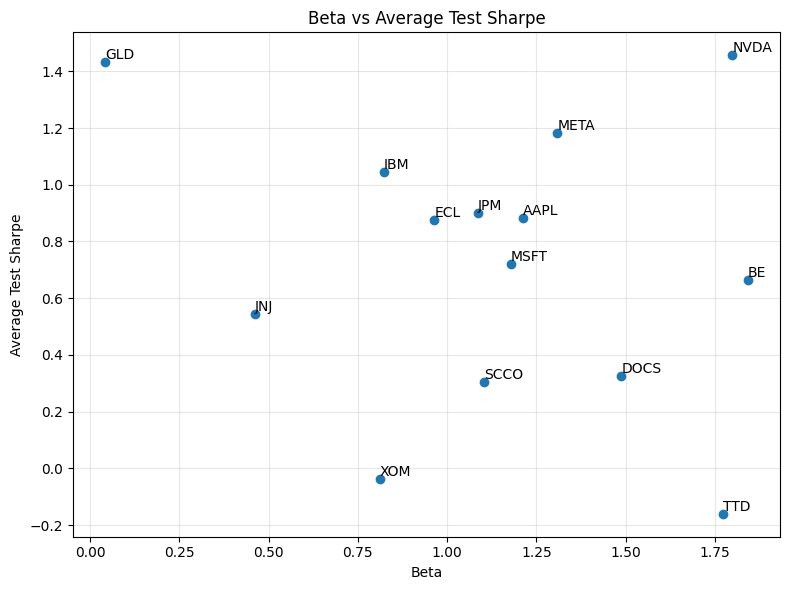

In [134]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Beta"],
    df["Avg Test Sharpe"]
)

for _, row in df.iterrows():
    plt.text(
        row["Beta"],
        row["Avg Test Sharpe"],
        row["Asset"],
        ha="left",
        va="bottom"
    )

plt.xlabel("Beta")
plt.ylabel("Average Test Sharpe")
plt.title("Beta vs Average Test Sharpe")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cross Sectional Analysis

In [135]:
assets_df = pd.read_csv("../outputs/experiment_results.csv")

asset_avg_sharpe = (
    assets_df.groupby("Asset")["Test Sharpe"]
            .mean()
            .sort_values(ascending=False)
)

In [136]:
columns = ['Asset', 'Beta', 'Avg Returns', 'Avg Volatility', 'Best Strategy', 'Best Test Sharpe']
df = pd.DataFrame(columns = columns)

In [137]:
assets = ['AAPL', 'MSFT','NVDA','TTD','DOCS','IBM','BE','XOM','GLD','JNJ','SCCO','ECL','JPM','META']

In [138]:
for asset in assets:
    asset_df = get_data(asset, "2016-01-01", "2026-01-01")
    asset_df = generate_features(asset_df)
    asset_outcomes = assets_df[assets_df['Asset'] == asset]
    combined = pd.concat(
        [
            asset_df["returns"],
            spy_df["returns"]
        ],
        axis=1
    ).dropna()

    beta = calculate_beta(
        combined.iloc[:, 0],
        combined.iloc[:, 1]
    )

    best_row = asset_outcomes.loc[asset_outcomes['Test Sharpe'].idxmax()]

    df.loc[len(df)] = [
        asset, 
        beta, 
        asset_df['returns'].mean(), 
        asset_df['volatility'].mean(), 
        best_row['Strategy'], 
        best_row['Test Sharpe']
    ]

df.sort_values('Best Test Sharpe', ascending = False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/var/folders/f5/793n94tx3jj8c_rrt1drx2g40000gn/T/ipykernel_68201/2048592113.py:5: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(
[*********************100%***********************]  1 of 1 completed
/var/folders/f5/793n94tx3jj8c_rrt1drx2g40000gn/T/ipykernel_68201/2048592113.py:5: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True`

,Asset,Beta,Avg Returns,Avg Volatility,Best Strategy,Best Test Sharpe
8,GLD,0.041616,0.000580,0.008703,Random Forest,2.111895
2,NVDA,1.798033,0.002657,0.028976,Logistic Regression,1.972225
12,JPM,1.086492,0.000797,0.014996,Momentum + Rolling Volatility,1.916430
13,META,1.307990,0.001040,0.021412,Logistic Regression,1.884032
5,IBM,0.821961,0.000451,0.013995,Momentum,1.778768
11,ECL,0.964061,0.000462,0.013365,Random Forest,1.745442
0,AAPL,1.213043,0.001097,0.016457,Random Forest,1.544303
6,BE,1.842010,0.002372,0.053618,Momentum + Trend Strength,1.442981
9,JNJ,0.462261,0.000355,0.010314,Momentum,1.396559
1,MSFT,1.178747,0.001009,0.015196,Logistic Regression,1.218092


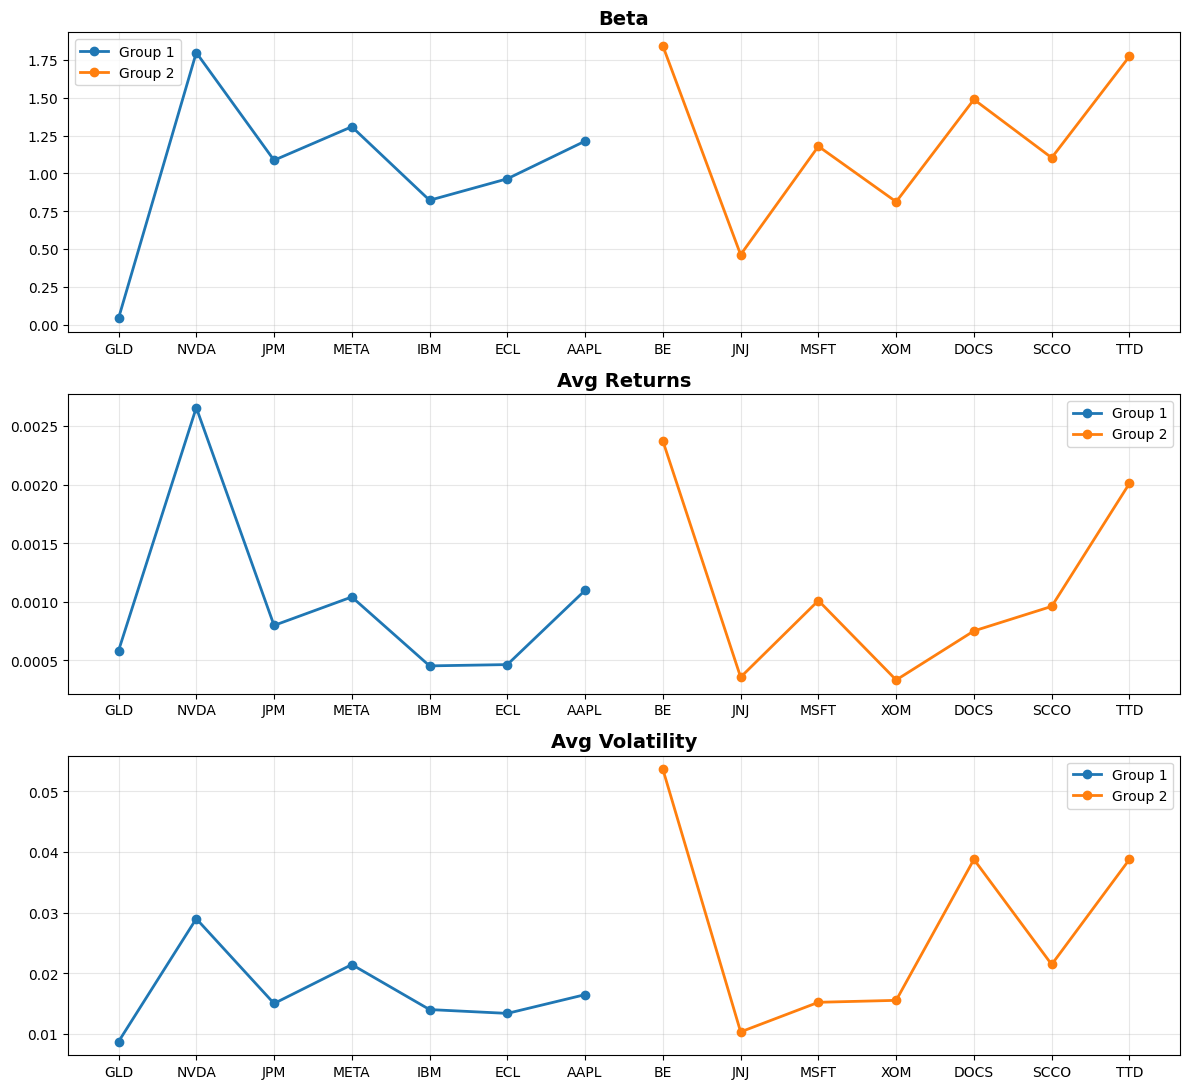

In [139]:
df = df.sort_values('Best Test Sharpe', ascending = False)

group1 = df.iloc[:7]
group2 = df.iloc[7:]

metrics = ['Beta','Avg Returns','Avg Volatility']

fig, axes = plt.subplots(
    nrows=len(metrics),
    ncols=1,
    figsize=(12, 11)
)

for ax, metric in zip(axes, metrics):

    ax.plot(
        group1['Asset'],
        group1[metric],
        marker='o',
        linewidth=2,
        label='Group 1'
    )

    ax.plot(
        group2['Asset'],
        group2[metric],
        marker='o',
        linewidth=2,
        label='Group 2'
    )

    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [140]:
assets_to_avg = ['GLD', 'NVDA', 'JPM', 'META', 'IBM', 'ECL', 'AAPL', 'BE', 'JNJ', 'MSFT', 'XOM', 'DOCS', 'SCCO', 'TTD']
columns = ['Asset', 'Momentum', 'Trend Strength', 'Volume Ratio', 'RSI', 'Distance MA']
df = pd.DataFrame(columns = columns)


for asset in assets_to_avg:
    asset_df = get_data(asset, "2016-01-01", "2026-01-01")
    asset_df = generate_features(asset_df)
    df.loc[len(df)] = [
        asset,
        asset_df['momentum'].mean(),
        asset_df['trend_strength'].mean(),
        asset_df['volume_ratio'].mean(),
        asset_df['rsi'].mean(),
        asset_df['distance_ma20'].mean()
    ]

df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Asset,Momentum,Trend Strength,Volume Ratio,RSI,Distance MA
0,GLD,0.011493,0.007483,1.010748,53.459015,0.005199
1,NVDA,0.054327,0.034230,1.007113,56.803513,0.022496
2,JPM,0.016133,0.010384,1.003408,54.797854,0.006919
3,META,0.020238,0.011345,1.008994,54.498763,0.007912
4,IBM,0.009867,0.005662,1.008210,52.519827,0.003902
5,ECL,0.009120,0.005640,1.010353,53.359096,0.003775
6,AAPL,0.022579,0.014957,1.000940,56.060051,0.009648
7,BE,0.057295,0.012647,1.026157,49.947351,0.012480
8,JNJ,0.007035,0.004166,1.007310,52.823608,0.002972
9,MSFT,0.019748,0.013778,1.003399,55.758268,0.008753


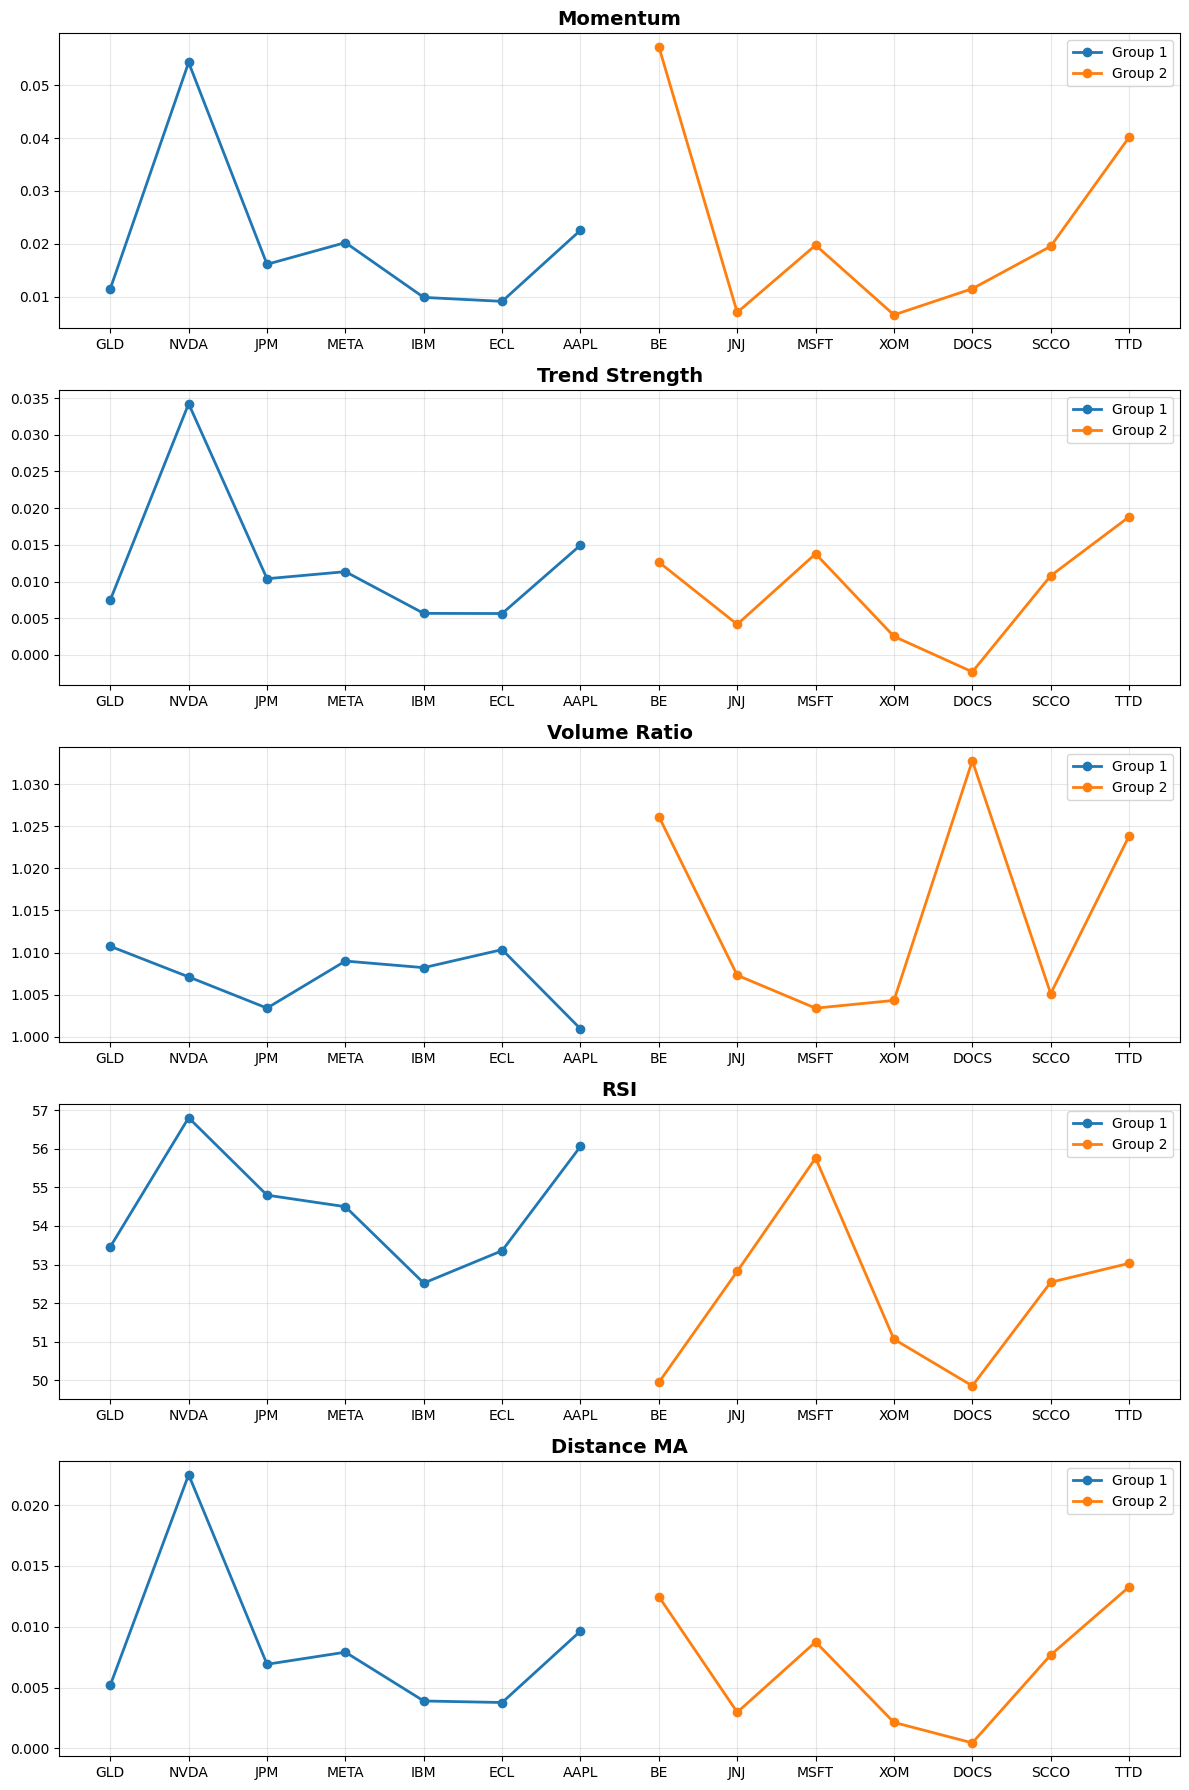

In [141]:
group1 = df.iloc[:7]
group2 = df.iloc[7:]

metrics = ['Momentum','Trend Strength','Volume Ratio','RSI','Distance MA']

fig, axes = plt.subplots(
    nrows=len(metrics),
    ncols=1,
    figsize=(12, 18)
)

for ax, metric in zip(axes, metrics):

    ax.plot(
        group1['Asset'],
        group1[metric],
        marker='o',
        linewidth=2,
        label='Group 1'
    )

    ax.plot(
        group2['Asset'],
        group2[metric],
        marker='o',
        linewidth=2,
        label='Group 2'
    )

    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()